# Amazon Sales Analysis — Python EDA

This notebook contains exploratory data analysis of the cleaned Amazon sales dataset.

The analysis focuses on:
- Order status and order value
- Sales trends over time
- Product performance
- B2B vs B2C
- Fulfilment and sales channels
- Geographic performance
- Failed and returned orders

**Dataset period:** March 31, 2022 – June 29, 2022

## 1. Setup and Data Loading

In [1]:
from getpass import getpass

import pandas as pd
import matplotlib.pyplot as plt

from sqlalchemy import create_engine, URL

In [2]:
password = getpass("PostgreSQL password: ")

url = URL.create(
    drivername="postgresql+psycopg",
    username="postgres",
    password=password,
    host="localhost",
    port=5432,
    database="postgres"
)

engine = create_engine(url)

In [3]:
df = pd.read_sql(
    "SELECT * FROM public.amazon_sales_clean;",
    engine
)
df.head()

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by
0,50678,403-3792726-5856342,2022-05-30,Shipped,Amazon,Amazon.in,Expedited,J0397,J0397-DR-S,Western Dress,...,1,INR,999.0,NEW TOWN,WEST BENGAL,700156,IN,NaN,False,NaN
1,50868,407-0699097-6955533,2022-05-30,Cancelled,Merchant,Amazon.in,Standard,J0380,J0380-SKD-M,Set,...,0,NaN,NaN,JAIPUR,RAJASTHAN,302039,IN,NaN,False,Easy Ship
2,51628,403-0459125-3553169,2022-05-29,Cancelled,Amazon,Amazon.in,Expedited,JNE3373,JNE3373-KR-XXXL,kurta,...,0,NaN,NaN,PUNE,MAHARASHTRA,411037,IN,NaN,False,NaN
3,53111,171-9287801-4438729,2022-05-28,Shipped,Amazon,Amazon.in,Expedited,SET048,SET048-KR-NP-XS,Set,...,1,INR,648.0,FARIDABAD,HARYANA,121003,IN,NaN,False,NaN
4,50653,404-5242736-6957962,2022-05-30,Shipped - Returned to Seller,Merchant,Amazon.in,Standard,JNE3797,JNE3797-KR-A-L,Western Dress,...,1,INR,771.0,MALDA,WEST BENGAL,732101,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship


In [4]:
df.shape

(128975, 23)

In [5]:
df.dtypes

index                   int64
Order ID                  str
Date                   object
Status                    str
Fulfilment                str
Sales Channel             str
ship-service-level        str
Style                     str
SKU                       str
Category                  str
Size                      str
ASIN                      str
Courier Status            str
Qty                     int64
currency                  str
Amount                float64
ship-city                 str
ship-state                str
ship-postal-code          str
ship-country              str
promotion-ids             str
B2B                      bool
fulfilled-by              str
dtype: object

In [6]:
df["Date"] = pd.to_datetime(df["Date"])
df["Date"].dtype

dtype('<M8[s]')

## 2. Order Status Preparation

In [7]:
df["Status"].value_counts(dropna=False)

Status
Shipped                          77804
Shipped - Delivered to Buyer     28769
Cancelled                        18332
Shipped - Returned to Seller      1953
Shipped - Picked Up                973
Pending                            658
Pending - Waiting for Pick Up      281
Shipped - Returning to Seller      145
Shipped - Out for Delivery          35
Shipped - Rejected by Buyer         11
Shipping                             8
Shipped - Lost in Transit            5
Shipped - Damaged                    1
Name: count, dtype: int64

In [8]:
def group_status(status):
    if status == "Shipped - Delivered to Buyer":
        return "Delivered"
    
    elif status in [
        "Shipped",
        "Shipped - Picked Up",
        "Shipped - Out for Delivery",
        "Shipping"
    ]:
        return "In Transit"
    
    elif status in [
        "Pending",
        "Pending - Waiting for Pick Up"
    ]:
        return "Pending"
    
    elif status in [
        "Shipped - Returned to Seller",
        "Shipped - Returning to Seller",
        "Shipped - Rejected by Buyer",
        "Shipped - Lost in Transit",
        "Shipped - Damaged"
    ]:
        return "Failed / Returned"
    
    elif status == "Cancelled":
        return "Cancelled"
    
    else:
        return "Other"

In [9]:
df["Status Group"] = df["Status"].apply(group_status)
df["Status Group"].value_counts()

Status Group
In Transit           78820
Delivered            28769
Cancelled            18332
Failed / Returned     2115
Pending                939
Name: count, dtype: int64

In [10]:
status_groups_per_order = (
    df.groupby("Order ID")["Status Group"]
    .nunique()
)

status_groups_per_order.value_counts().sort_index()

Status Group
1    120378
Name: count, dtype: int64

## 3. Order Status Analysis

In [11]:
orders_by_status = (
    df.groupby("Status Group")["Order ID"]
    .nunique()
    .sort_values(ascending=False)
)

orders_by_status

Status Group
In Transit           73784
Delivered            26566
Cancelled            17185
Failed / Returned     1997
Pending                846
Name: Order ID, dtype: int64

In [12]:
order_status_percent = (
    orders_by_status
    .div(df["Order ID"].nunique())
    .mul(100)
    .round(2)
)

order_status_percent

Status Group
In Transit           61.29
Delivered            22.07
Cancelled            14.28
Failed / Returned     1.66
Pending               0.70
Name: Order ID, dtype: float64

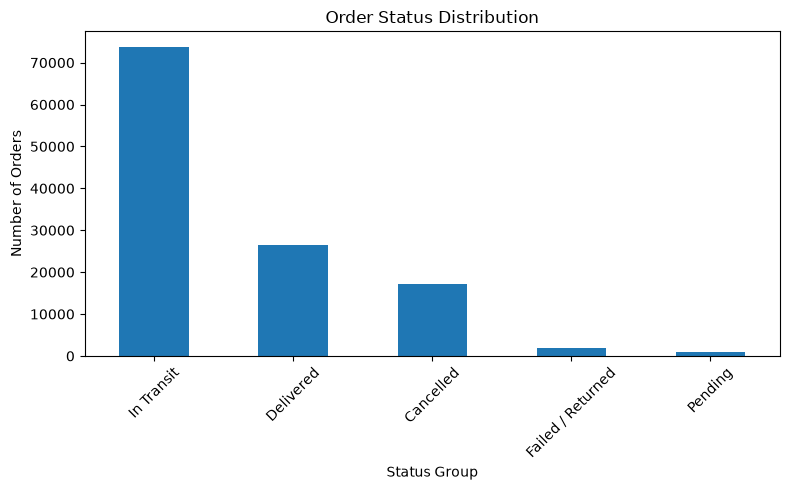

In [13]:
orders_by_status.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Order Status Distribution")
plt.xlabel("Status Group")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4. Order-Level and Monetary Analysis

In [14]:
order_level = (
    df.groupby("Order ID", as_index=False)
    .agg(
        Date=("Date", "min"),
        Status_Group=("Status Group", "first"),
        Order_Amount=("Amount", lambda x: x.sum(min_count=1)),
        Units=("Qty", "sum"),
        Has_Missing_Amount=("Amount", lambda x: x.isna().any())
    )
)

In [16]:
order_level["Has_Missing_Amount"].value_counts()

Has_Missing_Amount
False    112929
True       7449
Name: count, dtype: int64

In [17]:
pd.crosstab(
    order_level["Status_Group"],
    order_level["Has_Missing_Amount"]
)

Has_Missing_Amount,False,True
Status_Group,,
Cancelled,9956,7229
Delivered,26558,8
Failed / Returned,1994,3
In Transit,73577,207
Pending,844,2


In [18]:
order_value_valid = order_level[
    ~order_level["Has_Missing_Amount"]
].copy()

In [19]:
value_by_status = (
    order_value_valid
    .groupby("Status_Group")
    .agg(
        Orders=("Order ID", "nunique"),
        Total_Order_Value=("Order_Amount", "sum"),
        Average_Order_Value=("Order_Amount", "mean")
    )
    .round(2)
)

value_by_status

,Orders,Total_Order_Value,Average_Order_Value
Status_Group,,,
Cancelled,9956,6913953.51,694.45
Delivered,26558,18645031.00,702.05
Failed / Returned,1994,1385604.00,694.89
In Transit,73577,50943543.00,692.38
Pending,844,620894.00,735.66


## 5. Time Analysis

In [20]:
delivered_orders = order_value_valid[
    order_value_valid["Status_Group"] == "Delivered"
].copy()
delivered_orders.shape

(26558, 6)

In [21]:
daily_delivered_value = (
    delivered_orders
    .groupby("Date")["Order_Amount"]
    .sum()
    .sort_index()
)

daily_delivered_value.head()

Date
2022-03-31     10170.0
2022-04-01    146361.0
2022-04-02    147739.0
2022-04-03    185368.0
2022-04-04    180985.0
Name: Order_Amount, dtype: float64

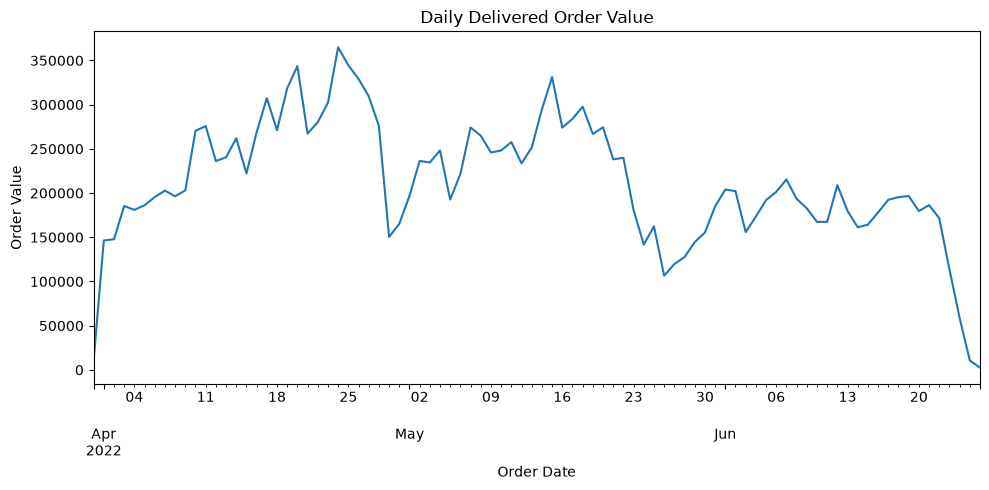

In [22]:
daily_delivered_value.plot(
    figsize=(10, 5)
)

plt.title("Daily Delivered Order Value")
plt.xlabel("Order Date")
plt.ylabel("Order Value")
plt.tight_layout()
plt.show()

In [23]:
daily_delivered_ma7 = (
    daily_delivered_value
    .rolling(window=7)
        .mean()
)

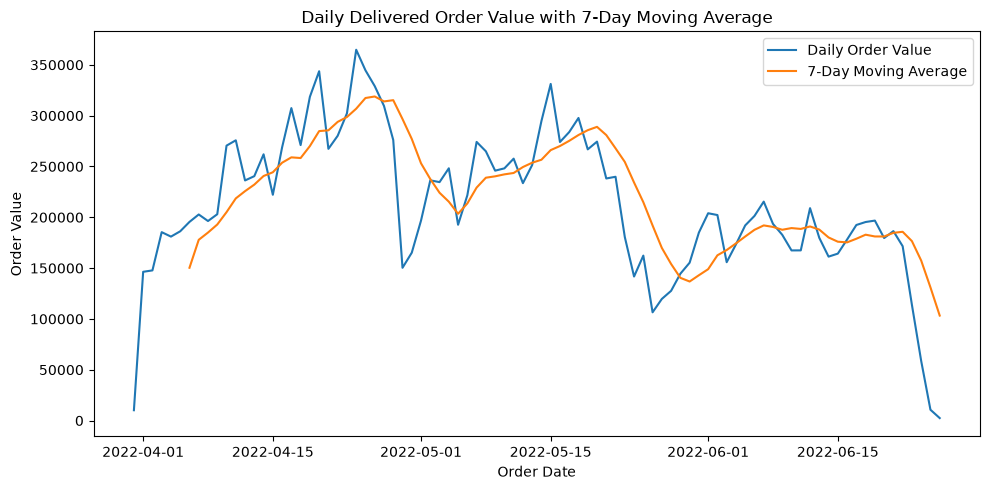

In [24]:
plt.figure(figsize=(10, 5))

plt.plot(
    daily_delivered_value.index,
    daily_delivered_value.values,
    label="Daily Order Value"
)

plt.plot(
    daily_delivered_ma7.index,
    daily_delivered_ma7.values,
    label="7-Day Moving Average"
)

plt.title("Daily Delivered Order Value with 7-Day Moving Average")
plt.xlabel("Order Date")
plt.ylabel("Order Value")
plt.legend()
plt.tight_layout()
plt.show()

In [25]:
daily_delivered_orders = (
    delivered_orders
    .groupby("Date")["Order ID"]
    .nunique()
    .sort_index()
)

daily_delivered_orders.head()

Date
2022-03-31     16
2022-04-01    228
2022-04-02    234
2022-04-03    294
2022-04-04    279
Name: Order ID, dtype: int64

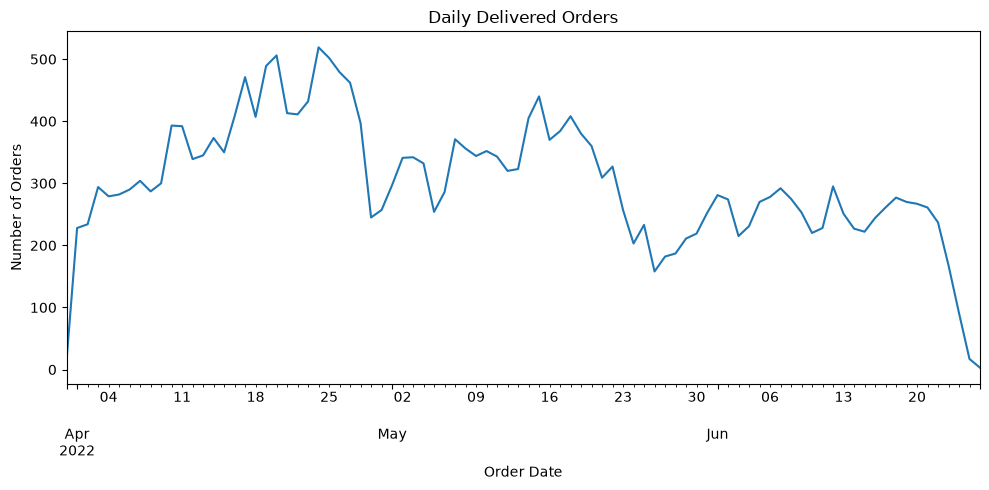

In [26]:
daily_delivered_orders.plot(
    figsize=(10, 5)
)

plt.title("Daily Delivered Orders")
plt.xlabel("Order Date")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()

In [27]:
daily_aov = (
    delivered_orders
    .groupby("Date")["Order_Amount"]
    .mean()
    .sort_index()
)

daily_aov.head()

Date
2022-03-31    635.625000
2022-04-01    641.934211
2022-04-02    631.363248
2022-04-03    630.503401
2022-04-04    648.691756
Name: Order_Amount, dtype: float64

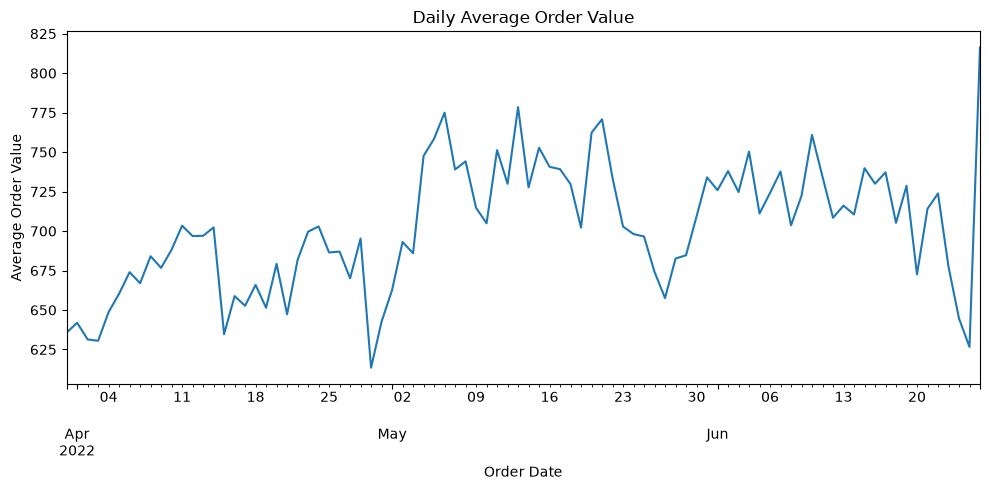

In [28]:
daily_aov.plot(
    figsize=(10, 5)
)

plt.title("Daily Average Order Value")
plt.xlabel("Order Date")
plt.ylabel("Average Order Value")
plt.tight_layout()
plt.show()

In [29]:
daily_summary = pd.DataFrame({
    "Orders": daily_delivered_orders,
    "Order_Value": daily_delivered_value,
    "AOV": daily_aov
})

daily_summary.head()

,Orders,Order_Value,AOV
Date,,,
2022-03-31,16,10170.0,635.625000
2022-04-01,228,146361.0,641.934211
2022-04-02,234,147739.0,631.363248
2022-04-03,294,185368.0,630.503401
2022-04-04,279,180985.0,648.691756


In [30]:
daily_summary.corr().round(2)

,Orders,Order_Value,AOV
Orders,1.00,0.99,0.00
Order_Value,0.99,1.00,0.15
AOV,0.00,0.15,1.00


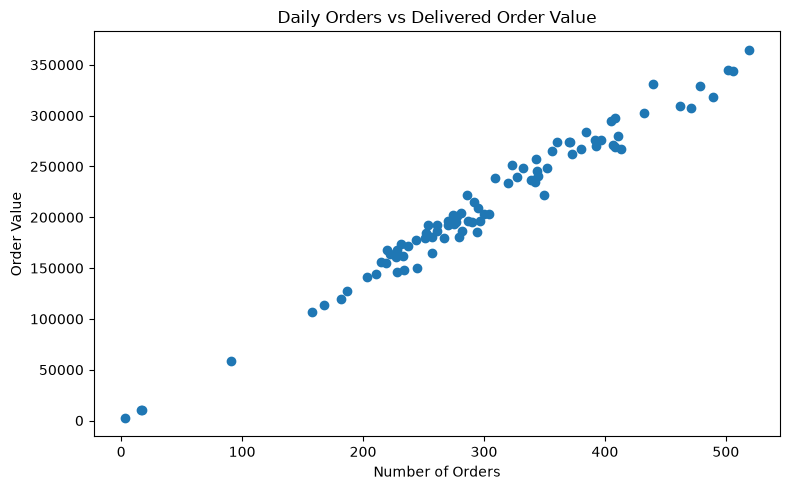

In [31]:
plt.figure(figsize=(8, 5))

plt.scatter(
    daily_summary["Orders"],
    daily_summary["Order_Value"]
)

plt.title("Daily Orders vs Delivered Order Value")
plt.xlabel("Number of Orders")
plt.ylabel("Order Value")
plt.tight_layout()
plt.show()

In [32]:
weekly_summary = (
    delivered_orders
    .set_index("Date")
    .resample("W")
    .agg(
        Orders=("Order ID", "nunique"),
        Order_Value=("Order_Amount", "sum"),
        AOV=("Order_Amount", "mean")
    )
)

weekly_summary

,Orders,Order_Value,AOV
Date,,,
2022-04-03,772,489638.0,634.246114
2022-04-10,2135,1435197.0,672.223419
2022-04-17,2678,1812711.0,676.889843
2022-04-24,3177,2147782.0,676.040919
2022-05-01,2639,1771512.0,671.281546
2022-05-08,2282,1672499.0,732.909290
2022-05-15,2527,1862578.0,737.070835
2022-05-22,2538,1874879.0,738.723010
2022-05-29,1431,982929.0,686.882600


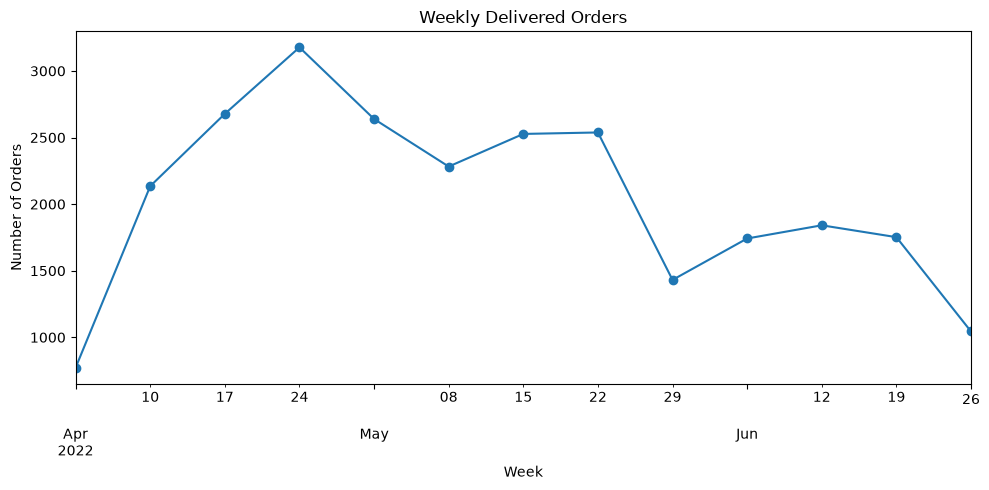

In [33]:
weekly_summary["Orders"].plot(
    figsize=(10, 5),
    marker="o"
)

plt.title("Weekly Delivered Orders")
plt.xlabel("Week")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()

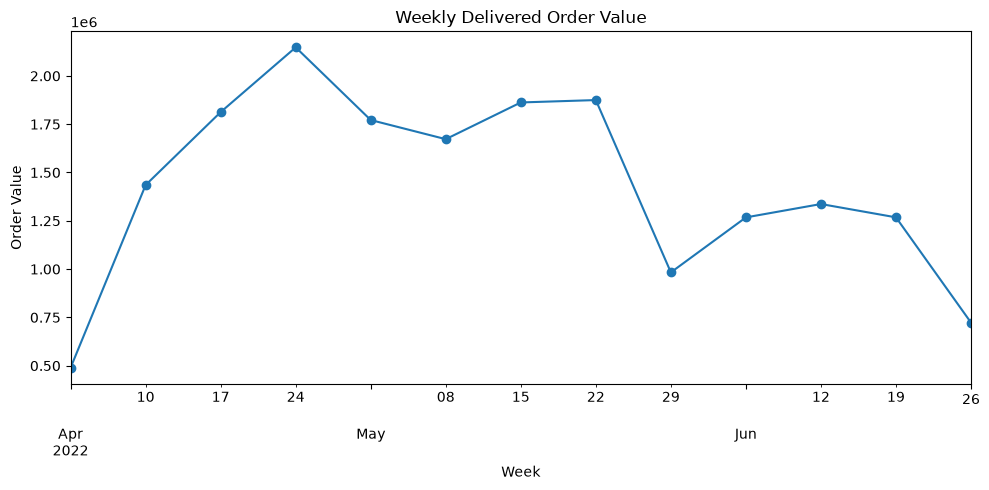

In [34]:
weekly_summary["Order_Value"].plot(
    figsize=(10, 5),
    marker="o"
)

plt.title("Weekly Delivered Order Value")
plt.xlabel("Week")
plt.ylabel("Order Value")
plt.tight_layout()
plt.show()

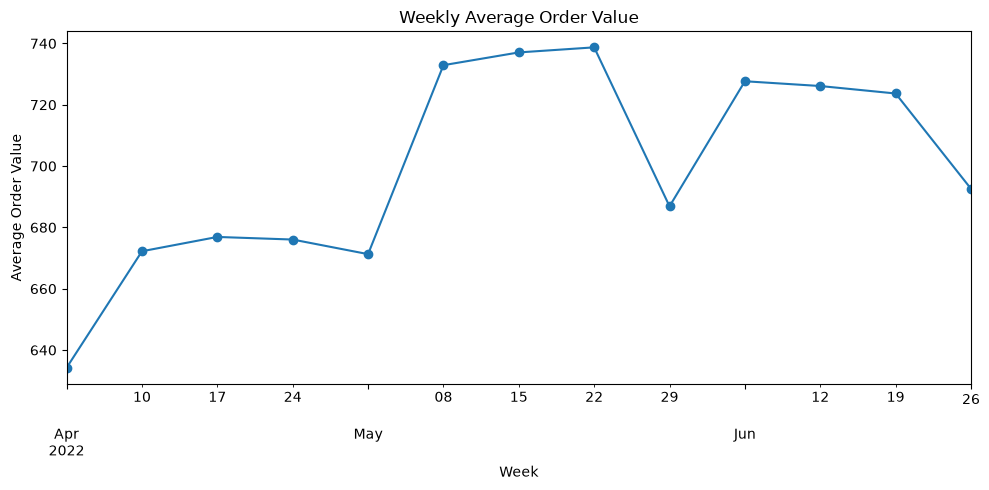

In [35]:
weekly_summary["AOV"].plot(
    figsize=(10, 5),
    marker="o"
)

plt.title("Weekly Average Order Value")
plt.xlabel("Week")
plt.ylabel("Average Order Value")
plt.tight_layout()
plt.show()

## 6. Product Performance

In [36]:
delivered_lines = df[
    df["Status Group"] == "Delivered"
].copy()

### Category Performance

In [37]:
category_performance = (
    delivered_lines
    .groupby("Category")
    .agg(
        Orders=("Order ID", "nunique"),
        Units=("Qty", "sum"),
        Order_Value=("Amount", lambda x: x.sum(min_count=1))
    )
    .sort_values("Order_Value", ascending=False)
)

category_performance

,Orders,Units,Order_Value
Category,,,
Set,10135,10675,8800562.0
kurta,9614,10497,4715208.0
Western Dress,4956,5216,3868616.0
Top,1828,1924,948734.0
Ethnic Dress,230,237,165465.0
Blouse,161,172,85444.0
Bottom,130,142,48615.0
Saree,16,23,18171.0


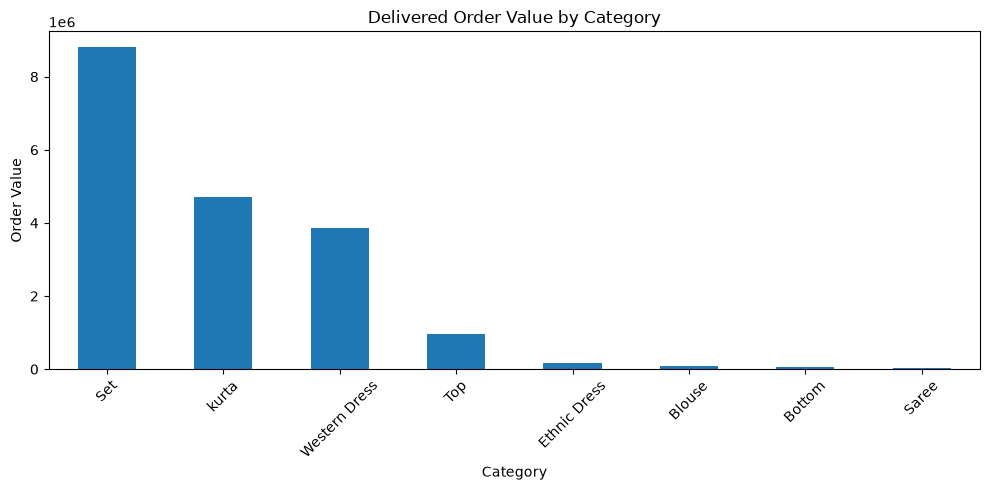

In [38]:
category_performance["Order_Value"].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Delivered Order Value by Category")
plt.xlabel("Category")
plt.ylabel("Order Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

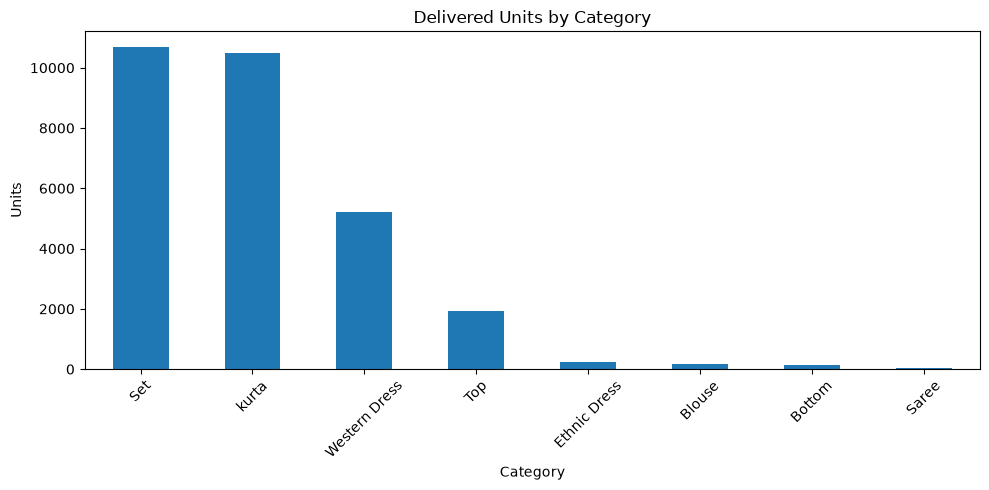

In [39]:
category_performance["Units"].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Delivered Units by Category")
plt.xlabel("Category")
plt.ylabel("Units")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### SKU Performance

In [40]:
sku_performance = (
    delivered_lines
    .groupby("SKU")
    .agg(
        Orders=("Order ID", "nunique"),
        Units=("Qty", "sum"),
        Order_Value=("Amount", lambda x: x.sum(min_count=1))
    )
    .sort_values("Order_Value", ascending=False)
)

sku_performance.head(10)

,Orders,Units,Order_Value
SKU,,,
JNE3797-KR-L,408,408,295061.0
JNE3797-KR-M,353,358,260255.0
SET183-KR-DH-M,262,262,197316.0
JNE3797-KR-S,258,259,188905.0
JNE3797-KR-XL,235,235,174942.0
JNE3797-KR-XXXL,164,165,121086.0
JNE3797-KR-XXL,168,168,117444.0
JNE3797-KR-XS,138,141,104323.0
J0003-SET-M,155,156,102058.0


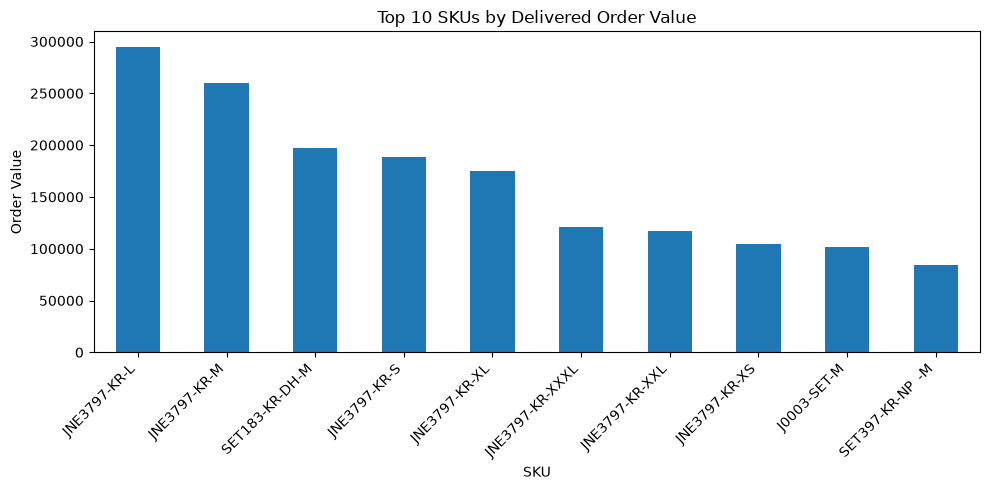

In [41]:
top_10_skus_value = sku_performance.head(10)

top_10_skus_value["Order_Value"].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Top 10 SKUs by Delivered Order Value")
plt.xlabel("SKU")
plt.ylabel("Order Value")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

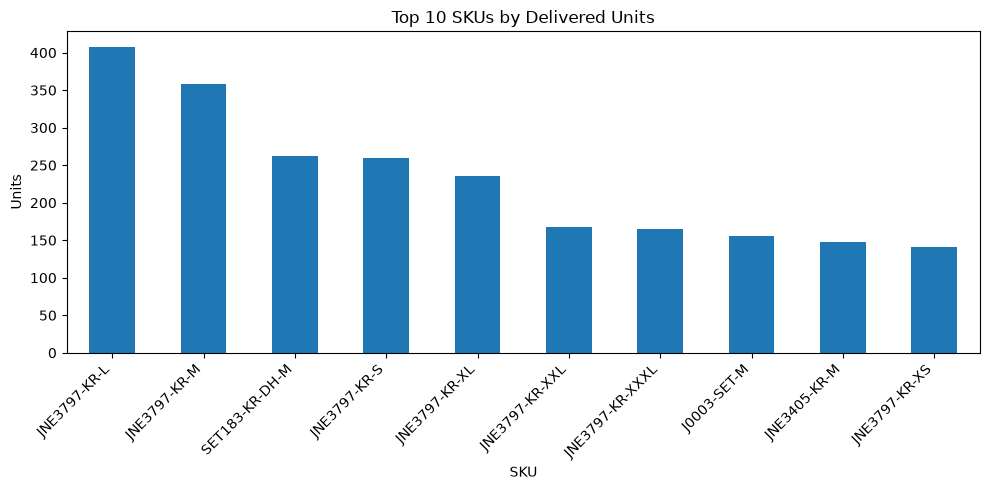

In [42]:
top_10_skus_units = (
    sku_performance
    .sort_values("Units", ascending=False)
    .head(10)
)

top_10_skus_units["Units"].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Top 10 SKUs by Delivered Units")
plt.xlabel("SKU")
plt.ylabel("Units")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Size Performance

In [43]:
size_performance = (
    delivered_lines
    .groupby("Size")
    .agg(
        Orders=("Order ID", "nunique"),
        Units=("Qty", "sum"),
        Order_Value=("Amount", lambda x: x.sum(min_count=1))
    )
    .sort_values("Units", ascending=False)
)

size_performance

,Orders,Units,Order_Value
Size,,,
M,4989,5270,3484046.0
L,4916,5246,3398038.0
XL,4633,4914,3075427.0
XXL,3794,4023,2470098.0
3XL,3281,3604,2306995.0
S,3320,3509,2339216.0
XS,1830,1930,1297507.0
6XL,138,157,117043.0
5XL,87,89,68214.0


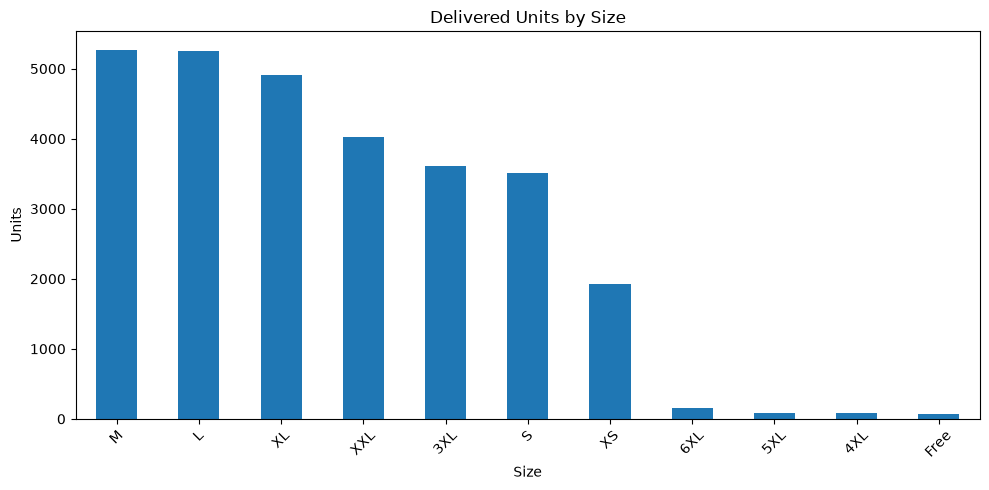

In [44]:
size_performance["Units"].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Delivered Units by Size")
plt.xlabel("Size")
plt.ylabel("Units")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

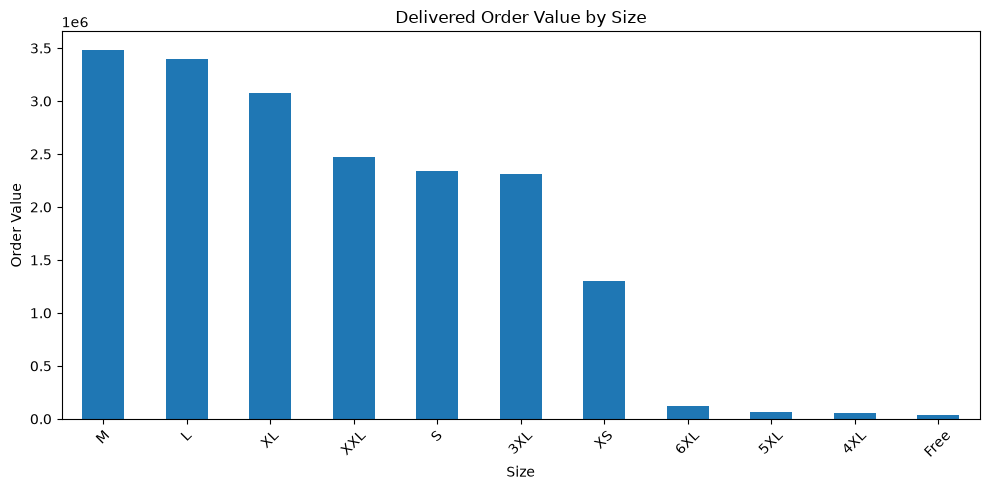

In [45]:
size_performance.sort_values(
    "Order_Value",
    ascending=False
)["Order_Value"].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Delivered Order Value by Size")
plt.xlabel("Size")
plt.ylabel("Order Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 7. Commercial and Fulfilment Analysis

### B2B vs B2C

In [46]:
b2b_per_order = (
    df.groupby("Order ID")["B2B"]
    .nunique()
)

b2b_per_order.value_counts().sort_index()

B2B
1    120378
Name: count, dtype: int64

In [50]:
order_b2b = (
    df.groupby("Order ID")["B2B"]
    .first()
)

order_value_valid["B2B"] = (
    order_level["Order ID"]
    .map(order_b2b)
)

In [51]:
b2b_performance = (
    order_value_valid
    .groupby("B2B")
    .agg(
        Orders=("Order ID", "nunique"),
        Order_Value=("Order_Amount", "sum"),
        AOV=("Order_Amount", "mean")
    )
    .round(2)
)

b2b_performance

,Orders,Order_Value,AOV
B2B,,,
False,112161,77918660.72,694.7
True,768,590364.79,768.7


In [52]:
b2b_status = pd.crosstab(
    order_value_valid["B2B"],
    order_value_valid["Status_Group"],
    normalize="index"
).mul(100).round(2)

b2b_status

Status_Group,Cancelled,Delivered,Failed / Returned,In Transit,Pending
B2B,,,,,
False,8.84,23.48,1.77,65.15,0.75
True,5.34,28.26,0.78,65.10,0.52


### Fulfilment

In [53]:
fulfilment_per_order = (
    df.groupby("Order ID")["Fulfilment"]
    .nunique()
)

fulfilment_per_order.value_counts().sort_index()

Fulfilment
1    120378
Name: count, dtype: int64

In [54]:
order_fulfilment = (
    df.groupby("Order ID")["Fulfilment"]
    .first()
)

order_level["Fulfilment"] = (
    order_level["Order ID"]
    .map(order_fulfilment)
)

order_value_valid["Fulfilment"] = (
    order_value_valid["Order ID"]
    .map(order_fulfilment)
)

In [55]:
fulfilment_performance = (
    order_value_valid
    .groupby("Fulfilment")
    .agg(
        Orders=("Order ID", "nunique"),
        Order_Value=("Order_Amount", "sum"),
        AOV=("Order_Amount", "mean")
    )
    .round(2)
)

fulfilment_performance

,Orders,Order_Value,AOV
Fulfilment,,,
Amazon,78213,54247732.00,693.59
Merchant,34716,24261293.51,698.85


In [56]:
fulfilment_status = pd.crosstab(
    order_level["Fulfilment"],
    order_level["Status_Group"],
    normalize="index"
).mul(100).round(2)

fulfilment_status

Status_Group,Cancelled,Delivered,Failed / Returned,In Transit,Pending
Fulfilment,,,,,
Amazon,12.86,0.00,0.00,86.71,0.43
Merchant,17.54,73.03,5.49,2.61,1.32


### Sales Channel

In [57]:
sales_channel_per_order = (
    df.groupby("Order ID")["Sales Channel"]
    .nunique()
)

sales_channel_per_order.value_counts().sort_index()

Sales Channel
1    120378
Name: count, dtype: int64

In [58]:
order_sales_channel = (
    df.groupby("Order ID")["Sales Channel"]
    .first()
)

order_level["Sales_Channel"] = (
    order_level["Order ID"]
    .map(order_sales_channel)
)

order_value_valid["Sales_Channel"] = (
    order_value_valid["Order ID"]
    .map(order_sales_channel)
)

In [59]:
sales_channel_performance = (
    order_value_valid
    .groupby("Sales_Channel")
    .agg(
        Orders=("Order ID", "nunique"),
        Order_Value=("Order_Amount", "sum"),
        AOV=("Order_Amount", "mean")
    )
    .round(2)
)

sales_channel_performance

,Orders,Order_Value,AOV
Sales_Channel,,,
Amazon.in,112929,78509025.51,695.21


In [60]:
sales_channel_status = pd.crosstab(
    order_level["Sales_Channel"],
    order_level["Status_Group"],
    normalize="index"
).mul(100).round(2)

sales_channel_status

Status_Group,Cancelled,Delivered,Failed / Returned,In Transit,Pending
Sales_Channel,,,,,
Amazon.in,14.29,22.09,1.66,61.25,0.7
Non-Amazon,0.81,0.00,0.00,99.19,0.0


## 8. Geographic Analysis

### State Performance

In [61]:
state_performance = (
    delivered_lines
    .groupby("ship-state")
    .agg(
        Orders=("Order ID", "nunique"),
        Units=("Qty", "sum"),
        Order_Value=("Amount", lambda x: x.sum(min_count=1))
    )
    .sort_values("Order_Value", ascending=False)
)

state_performance.head(10)

,Orders,Units,Order_Value
ship-state,,,
MAHARASHTRA,4582,4984,3135062.0
KARNATAKA,3350,3638,2279856.0
UTTAR PRADESH,2282,2452,1669881.0
TELANGANA,2140,2417,1551447.0
TAMIL NADU,2197,2424,1466364.0
KERALA,1567,1694,1079132.0
DELHI,1406,1537,1009947.0
ANDHRA PRADESH,1084,1199,772127.0
WEST BENGAL,1139,1205,749127.0


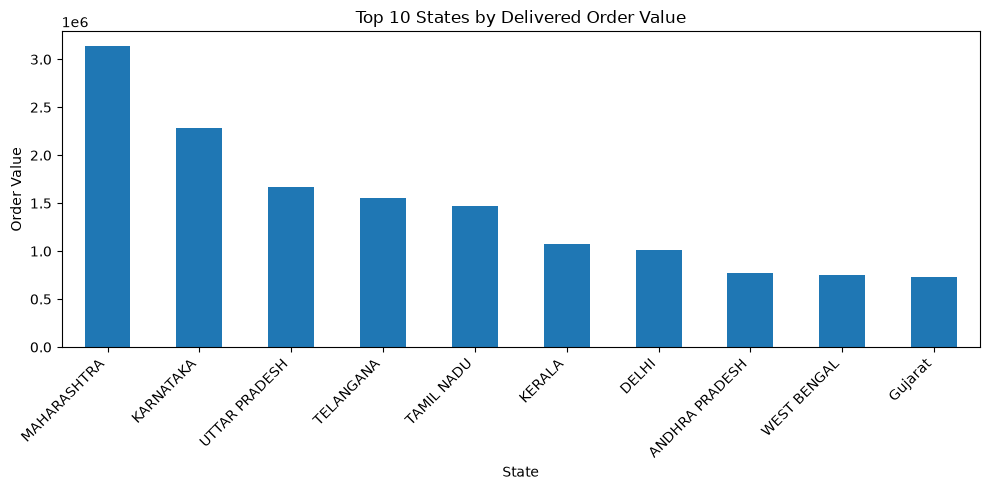

In [62]:
top_states = state_performance.head(10)

top_states["Order_Value"].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Top 10 States by Delivered Order Value")
plt.xlabel("State")
plt.ylabel("Order Value")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### City Performance

In [63]:
city_performance = (
    delivered_lines
    .groupby("ship-city")
    .agg(
        Orders=("Order ID", "nunique"),
        Units=("Qty", "sum"),
        Order_Value=("Amount", lambda x: x.sum(min_count=1))
    )
    .sort_values("Order_Value", ascending=False)
)

city_performance.head(10)

,Orders,Units,Order_Value
ship-city,,,
BENGALURU,2136,2336,1463928.0
HYDERABAD,1488,1689,1080750.0
MUMBAI,1308,1420,881790.0
NEW DELHI,1211,1319,866913.0
CHENNAI,968,1075,657872.0
PUNE,771,867,555966.0
KOLKATA,457,486,300486.0
GURUGRAM,350,368,247378.0
LUCKNOW,328,343,242735.0


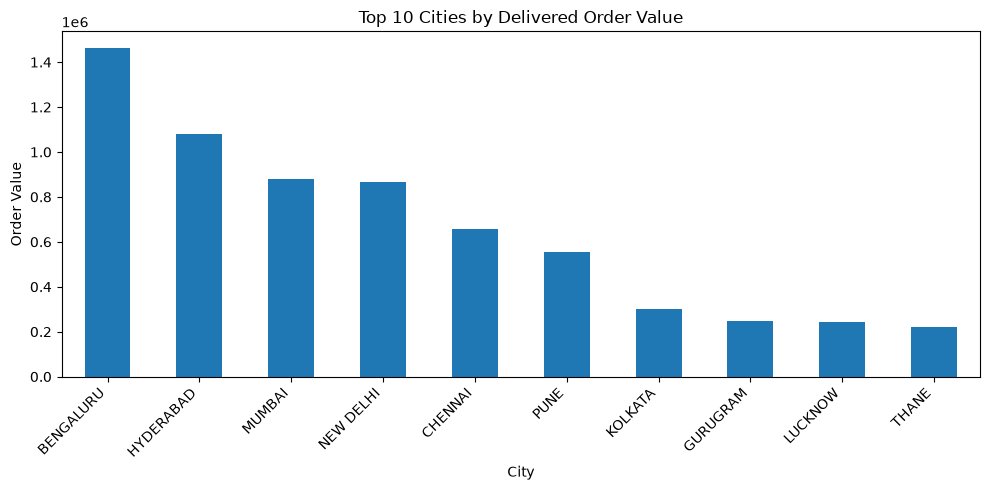

In [64]:
top_cities = city_performance.head(10)

top_cities["Order_Value"].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Top 10 Cities by Delivered Order Value")
plt.xlabel("City")
plt.ylabel("Order Value")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 9. Failure Analysis

In [65]:
failure_types = (
    df[df["Status Group"] == "Failed / Returned"]
    .groupby("Status")["Order ID"]
    .nunique()
    .sort_values(ascending=False)
)

failure_types

Status
Shipped - Returned to Seller     1851
Shipped - Returning to Seller     130
Shipped - Rejected by Buyer        11
Shipped - Lost in Transit           4
Shipped - Damaged                   1
Name: Order ID, dtype: int64

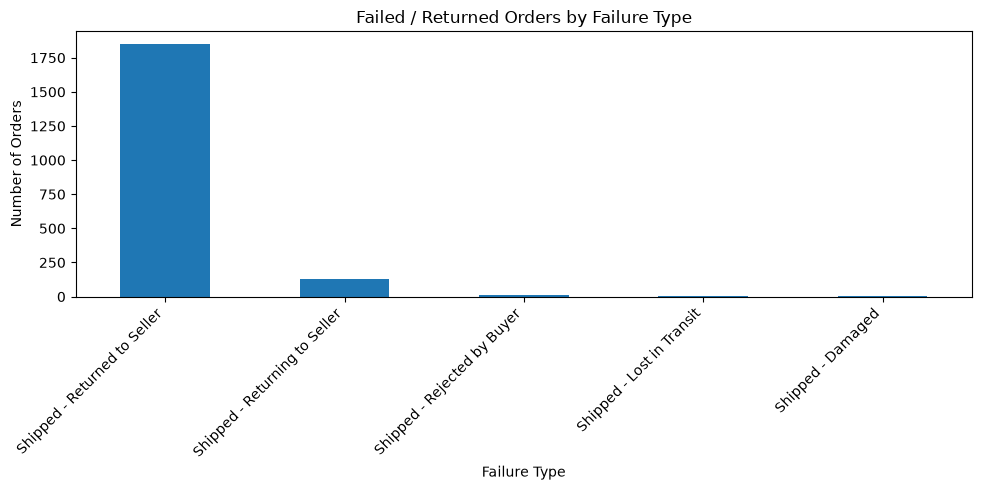

In [66]:
failure_types.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Failed / Returned Orders by Failure Type")
plt.xlabel("Failure Type")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [67]:
category_total_orders = (
    df.groupby("Category")["Order ID"]
    .nunique()
)

category_failed_orders = (
    df[df["Status Group"] == "Failed / Returned"]
    .groupby("Category")["Order ID"]
    .nunique()
)

category_failure = pd.DataFrame({
    "Total_Orders": category_total_orders,
    "Failed_Orders": category_failed_orders
}).fillna(0)

category_failure["Failure_Rate_%"] = (
    category_failure["Failed_Orders"]
    .div(category_failure["Total_Orders"])
    .mul(100)
    .round(2)
)

category_failure = category_failure.sort_values(
    "Failure_Rate_%",
    ascending=False
)

category_failure

,Total_Orders,Failed_Orders,Failure_Rate_%
Category,,,
Western Dress,14994,335.0,2.23
Set,47845,808.0,1.69
kurta,46561,716.0,1.54
Bottom,410,6.0,1.46
Ethnic Dress,1148,16.0,1.39
Blouse,897,12.0,1.34
Top,10155,127.0,1.25
Saree,144,1.0,0.69
Dupatta,2,0.0,0.00


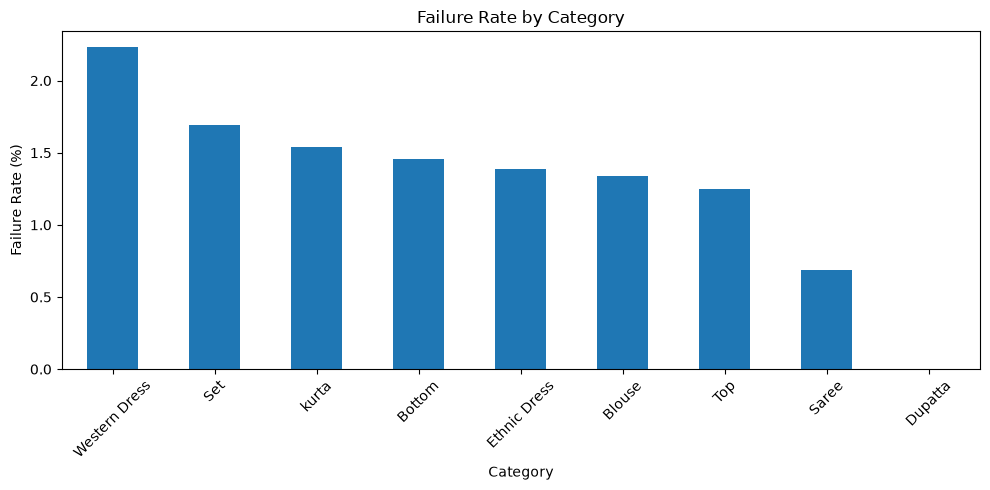

In [68]:
category_failure["Failure_Rate_%"].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Failure Rate by Category")
plt.xlabel("Category")
plt.ylabel("Failure Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [69]:
fulfilment_failure = (
    order_level
    .groupby("Fulfilment")
    .agg(
        Total_Orders=("Order ID", "nunique"),
        Failed_Orders=(
            "Status_Group",
            lambda x: (x == "Failed / Returned").sum()
        )
    )
)

fulfilment_failure["Failure_Rate_%"] = (
    fulfilment_failure["Failed_Orders"]
    .div(fulfilment_failure["Total_Orders"])
    .mul(100)
    .round(2)
)

fulfilment_failure

,Total_Orders,Failed_Orders,Failure_Rate_%
Fulfilment,,,
Amazon,84002,0,0.00
Merchant,36376,1997,5.49


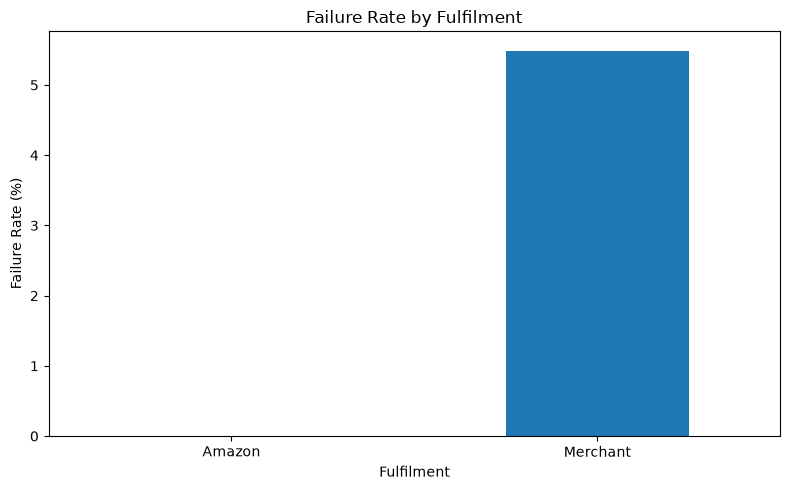

In [70]:
fulfilment_failure["Failure_Rate_%"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Failure Rate by Fulfilment")
plt.xlabel("Fulfilment")
plt.ylabel("Failure Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Key Insights

- Daily delivered order value is driven primarily by order volume rather than changes in average order value.
- Most orders are still classified as In Transit, while Delivered orders represent a smaller share of total orders.
- Missing Amount values are concentrated mainly in cancelled orders, so cancelled-order monetary metrics should be interpreted with caution.
- Set is the strongest delivered category by both units and order value, while JNE3797-KR-L is the top SKU by delivered order value.
- Medium (M) is the leading size by delivered units and order value, followed closely by Large (L).
- B2B orders represent a very small share of total orders but have a higher AOV than B2C orders.
- Fulfilment methods show very different status distributions, so fulfilment performance should not be judged directly from status rates alone.
- Most failed/returned orders are returns to seller rather than lost or damaged shipments.
- Western Dress has the highest observed category failure rate at 2.23%, while Set has the highest absolute number of failed orders.